<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB
None
           Feature1     Feature2
count   1020.000000  1020.000000
mean      11.436679   520.988235
std      313.061049    69.793442
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.828125   584.000000
max    10000.000000   640.000000


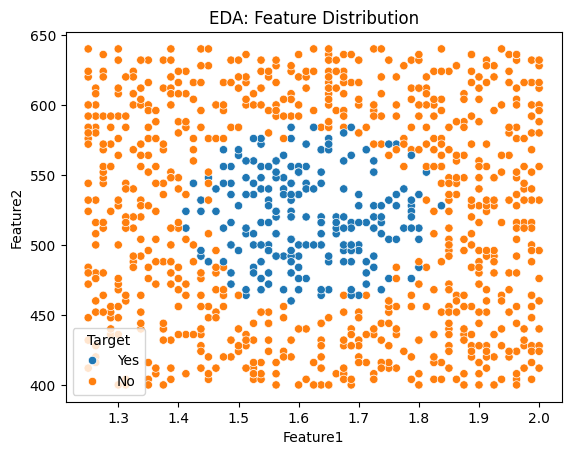

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Lab_Exam_binary_classification_dataset.csv")
print(data.info())
print(data.describe())
import seaborn as sns

data = pd.read_csv("Lab_Exam_binary_classification_dataset.csv")

# Remove missing values
data = data.dropna()

# Remove outliers
data = data[data['Feature1'] < 10]

# THEN plot
import seaborn as sns
sns.scatterplot(x=data['Feature1'], y=data['Feature2'], hue=data['Target'])
plt.title("EDA: Feature Distribution")
plt.show()

In [3]:
data = data.dropna()

In [5]:
# Remove extreme outliers
data = data[data['Feature1'] < 10]
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Target'] = le.fit_transform(data['Target'])

In [6]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

   Feature1  Feature2  Target
0    1.7250       520       1
1    1.8875       428       0
2    1.6000       552       1
3    1.4250       500       0
4    1.7750       628       0
Accuracy: 0.535
Confusion Matrix:
 [[88 77]
 [16 19]]


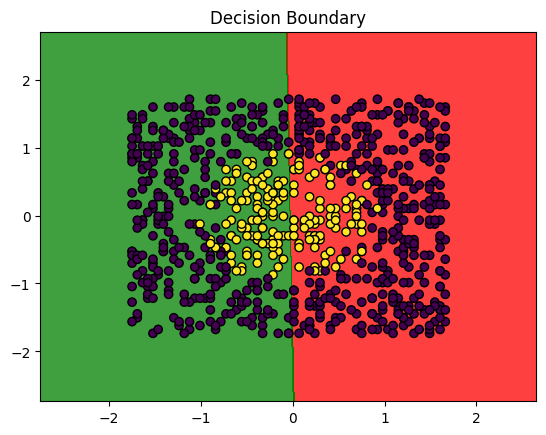

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Display first rows
print(data.head())

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Decision Boundary (ONLY works for 2 features)
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('#FF0000', '#008000')))

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k')
plt.title("Decision Boundary")
plt.show()

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.50      0.60       150
           1       0.26      0.52      0.34        50

    accuracy                           0.51       200
   macro avg       0.51      0.51      0.47       200
weighted avg       0.63      0.51      0.54       200



In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced'))
])

model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('logreg', LogisticRegression(class_weight='balanced'))])

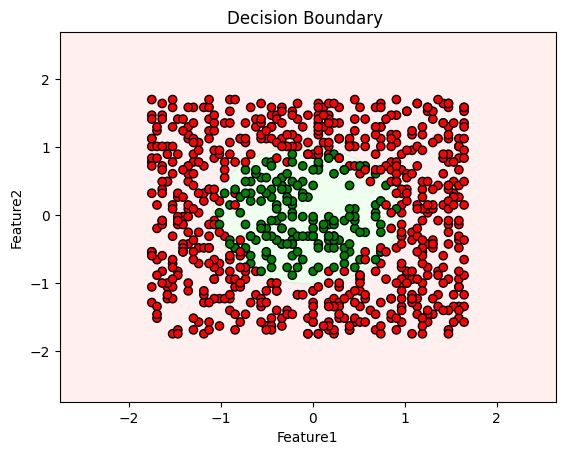

In [15]:
from matplotlib.colors import ListedColormap

# Use training data
X_set, y_set = X_train, y_train

# Create mesh grid
X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min()-1, X_set[:, 0].max()+1, 0.01),
    np.arange(X_set[:, 1].min()-1, X_set[:, 1].max()+1, 0.01)
)

# Predict using pipeline (IMPORTANT: no manual transform needed)
Z = model.predict(np.c_[X1.ravel(), X2.ravel()])
Z = Z.reshape(X1.shape)

# Plot decision boundary
plt.contourf(
    X1, X2, Z,
    alpha=0.3,
    cmap=ListedColormap(('#FFCCCC', '#CCFFCC'))
)

# Plot data points
plt.scatter(
    X_set[:, 0], X_set[:, 1],
    c=y_set,
    cmap=ListedColormap(('#FF0000', '#008000')),
    edgecolor='k'
)

plt.title("Decision Boundary ")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

In [13]:
# Predict using pipeline model
y_pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Final Accuracy: 0.96
Confusion Matrix:
 [[142   8]
 [  0  50]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       150
           1       0.86      1.00      0.93        50

    accuracy                           0.96       200
   macro avg       0.93      0.97      0.95       200
weighted avg       0.97      0.96      0.96       200

